In [66]:
import numpy as np
from scipy.signal import butter, filtfilt,iirnotch
import matplotlib.pyplot as plt
import wfdb  # reads MIT-BIH PhysioNet format

In [67]:
# Load record 100 from MIT-BIH Arrhythmia Database
# wfdb downloads it automatically from PhysioNet if not cached
record =wfdb.rdrecord('100',sampfrom=0,sampto=3600,pn_dir='mitdb')

In [68]:
# Extract the first channel (MLII lead)
ecg_signal = record.p_signal[:,0]
fs=record.fs  #Sampling frequency 

print(f"Sampling frequency: {fs} Hz")
print(f"Signal length : {len(ecg_signal)} samples")
print(f"Duration: {round(len(ecg_signal)/fs,1)} seconds")
print(f"Signal range : {round(ecg_signal.min(),3)} to {round(ecg_signal.max(),3)} mV")

Sampling frequency: 360 Hz
Signal length : 3600 samples
Duration: 10.0 seconds
Signal range : -0.645 to 0.96 mV


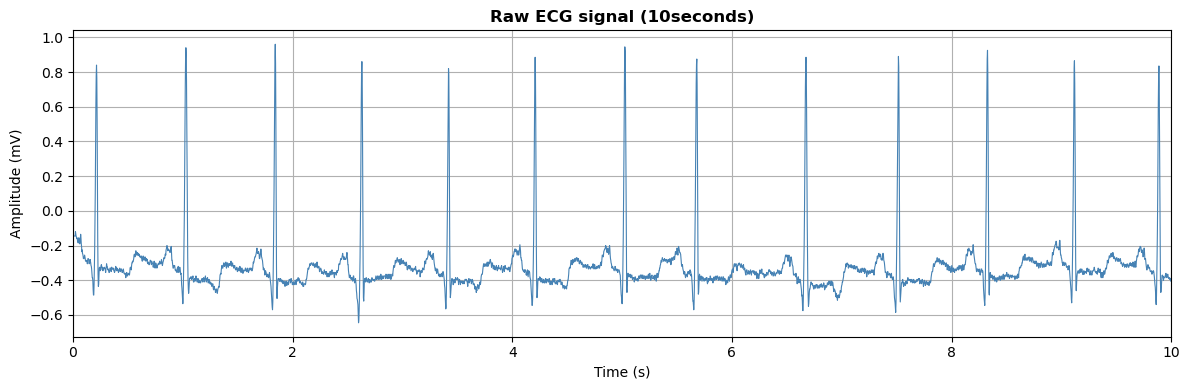

In [69]:
# Time axis
t=np.arange(len(ecg_signal))/fs

plt.figure(figsize=(12,4))
plt.plot(t,ecg_signal,color='steelblue',linewidth=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Raw ECG signal (10seconds)",weight ='bold')
plt.xlim([0,10])
plt.grid(True)
plt.tight_layout()
plt.savefig('output images/raw_ecg.png', dpi=150)
plt.show()

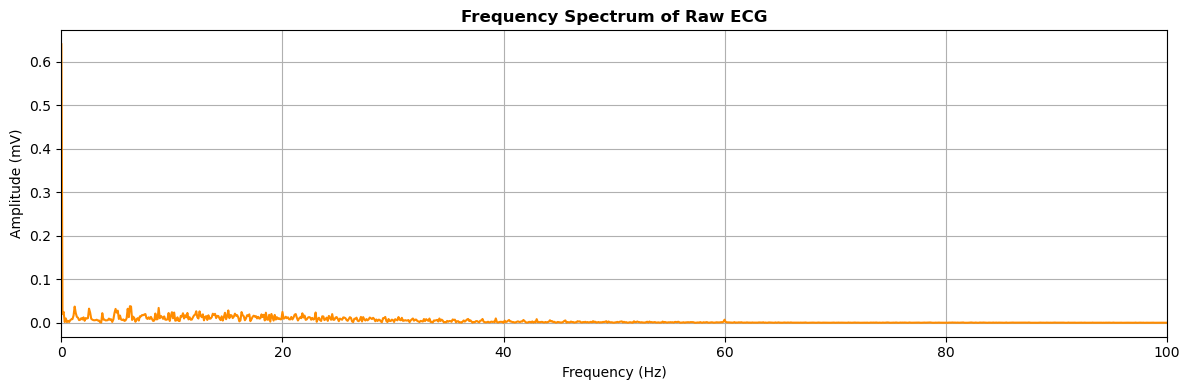

In [70]:
# FFT of Raw signal
n=len(ecg_signal)
fft_values=np.fft.rfft(ecg_signal)
fft_mag=2*np.abs(fft_values)/n
freq=np.fft.rfftfreq(n,1/fs)

plt.figure(figsize=(12,4))
plt.plot(freq,fft_mag,color='darkorange')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (mV)")
plt.title('Frequency Spectrum of Raw ECG',weight='bold')
plt.grid(True)
plt.xlim([0,100])
plt.tight_layout()
plt.savefig('output images/raw_ecg_spectrum.png', dpi=150)
plt.show()


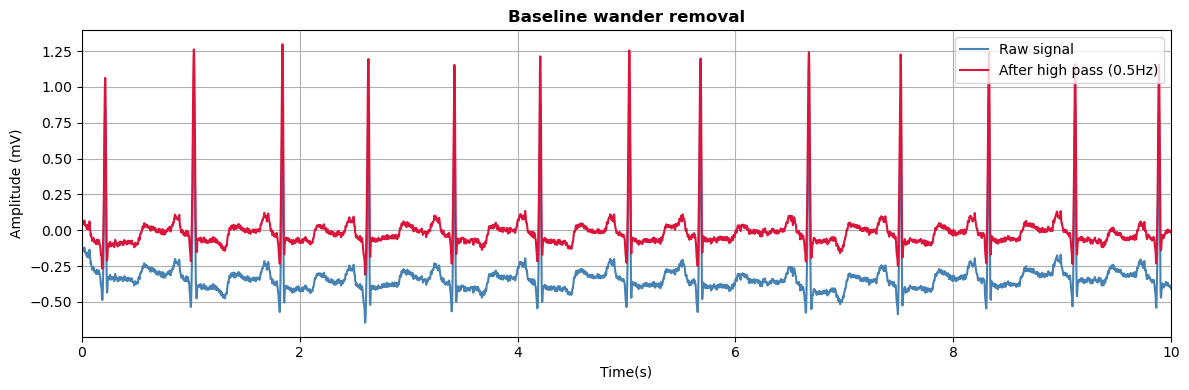

In [ ]:
def high_pass(signal,cutoff,fs,order=4):
    nyq=fs/2
    normal_cutoff=cutoff/nyq
    b,a=butter(order,normal_cutoff,btype='high')
    return filtfilt(b,a,signal)

# Remove baseline wander — cut everything below 0.5 Hz
ecg_hp=high_pass(ecg_signal,cutoff=0.5,fs=fs)

# Plot original vs filtered
t=np.arange(len(ecg_signal))/fs

plt.figure(figsize=(12,4))
plt.plot(t,ecg_signal,label='Raw signal',color='steelblue')
plt.plot(t,ecg_hp,color='crimson',label='After high pass (0.5Hz)')
plt.xlabel("Time(s)")
plt.ylabel("Amplitude (mV)")
plt.title("Baseline wander removal",weight='bold')
plt.xlim([0,10])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('output images/ecg_highpass.png', dpi=150)
plt.show()

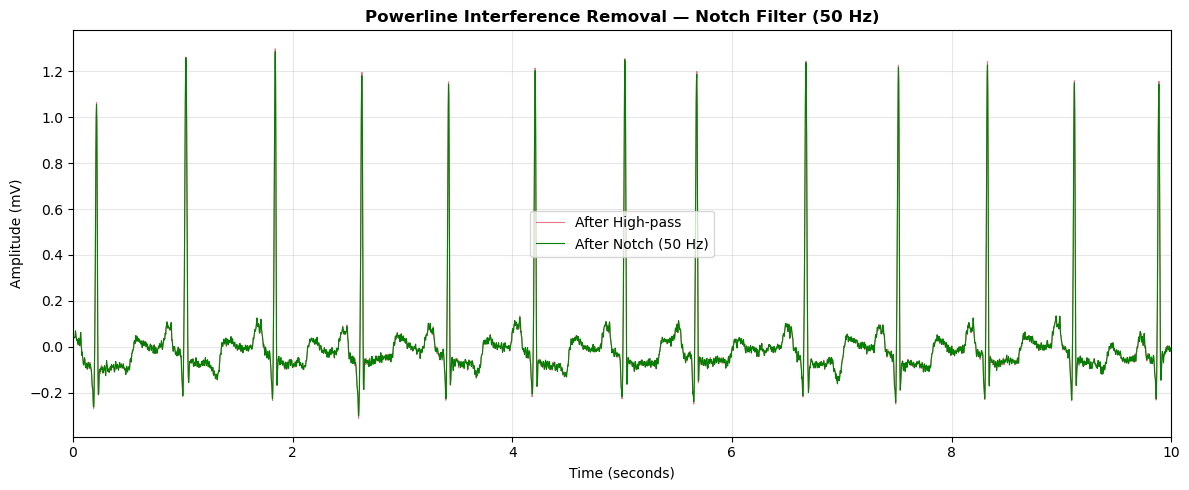

In [72]:
def notch_filter(signal,notch_freq,fs,quality_factor=30):
    b,a=iirnotch(notch_freq,quality_factor,fs)
    return filtfilt(b,a,signal)

# Apply notch at 50 Hz after high-pass
ecg_notch = notch_filter(ecg_hp,notch_freq=50,fs=fs)

plt.figure(figsize=(12, 5))
plt.plot(t, ecg_hp, label='After High-pass', color='crimson', alpha=0.6, linewidth=0.8)
plt.plot(t, ecg_notch, label='After Notch (50 Hz)', color='green', linewidth=0.8)
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (mV)')
plt.title('Powerline Interference Removal — Notch Filter (50 Hz)',weight='bold')
plt.legend()
plt.xlim([0, 10])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output images/ecg_notch.png', dpi=150)
plt.show()

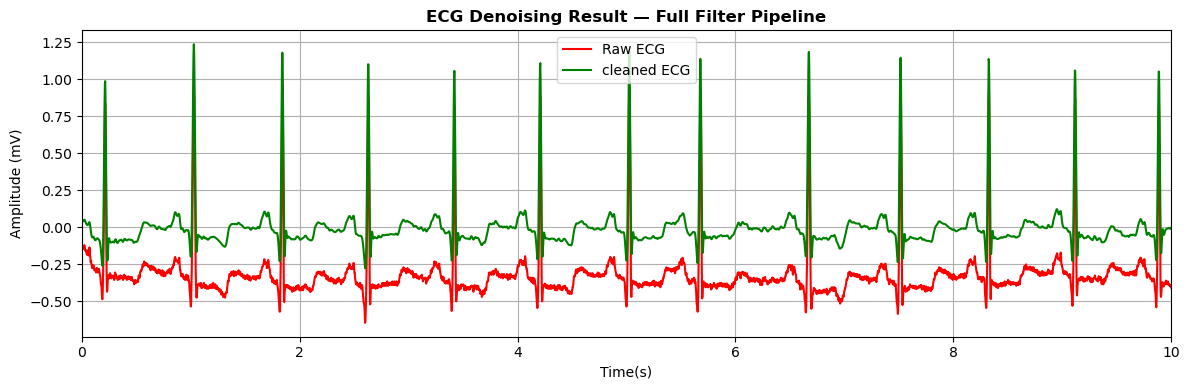

In [73]:
def low_pass(signal,cutoff,fs,order=4):
    nyq=fs/2
    normal_cutoff = cutoff/nyq
    b,a=butter(order,normal_cutoff,btype='low')
    return filtfilt(b,a,signal)

# Remove muscle artifact — cut everything above 40 Hz
ecg_clean=low_pass(ecg_notch,cutoff=40,fs=fs)

# Final comparison — raw vs fully cleaned
plt.figure(figsize=(12,4))
plt.plot(t,ecg_signal,color='red',label="Raw ECG")
plt.plot(t,ecg_clean,color="green",label='cleaned ECG')
plt.grid(True)
plt.legend()
plt.xlabel('Time(s)')
plt.ylabel("Amplitude (mV)")
plt.xlim([0,10])
plt.title('ECG Denoising Result — Full Filter Pipeline',weight='bold')
plt.tight_layout()
plt.savefig('output images/ecg_fully_cleaned.png', dpi=150)
plt.show()

In [74]:
def compute_snr(original,noise):
    signal_power =np.mean(original**2)
    noise_power=np.mean(noise**2)
    return 10*np.log10(signal_power/noise_power)

def compute_nrmse(refrence,estimated):
    rmse=np.sqrt(np.mean((refrence-estimated)**2))
    return rmse/(refrence.max()-refrence.min())

# Use ecg_clean as our reference (ground truth)
# Add synthetic noise to simulate a noisy recording
np.random.seed(42)
noise_level=0.1

# Three synthetic noise components
baseline=0.1*np.sin(2*np.pi*0.3*t)      # baseline wander
powerline=0.05*np.sin(2*np.pi*50*t)     # 50 Hz powerline
muscle=noise_level*np.random.rand(len(ecg_clean))   # muscle artifact

ecg_noisy=ecg_clean+baseline+powerline+muscle

# Apply full pipeline to the noisy signal
ecg_hp2=high_pass(ecg_noisy,cutoff=0.5,fs=fs)
ecg_notch2=notch_filter(ecg_hp2,notch_freq=50,fs=fs)
ecg_denoised =low_pass(ecg_notch2,cutoff=40,fs=fs)

# Compute metrics
snr_before=compute_snr(ecg_clean,ecg_noisy-ecg_clean)
snr_after =compute_snr(ecg_clean,ecg_denoised-ecg_clean)
snr_improvement=snr_after-snr_before

nrmse_before = compute_nrmse(ecg_clean, ecg_noisy)
nrmse_after = compute_nrmse(ecg_clean,ecg_denoised)
nrmse_reduction=((nrmse_before-nrmse_after)/nrmse_before)*100

print(f"SNR before filtering : {snr_before:.2f} dB")
print(f"SNR after filtering  : {snr_after:.2f} dB")
print(f"SNR improvement      : {snr_improvement:.2f} dB")
print(f"NRMSE before         : {nrmse_before:.4f}")
print(f"NRMSE after          : {nrmse_after:.4f}")




SNR before filtering : 4.55 dB
SNR after filtering  : 20.11 dB
SNR improvement      : 15.56 dB
NRMSE before         : 0.0646
NRMSE after          : 0.0108


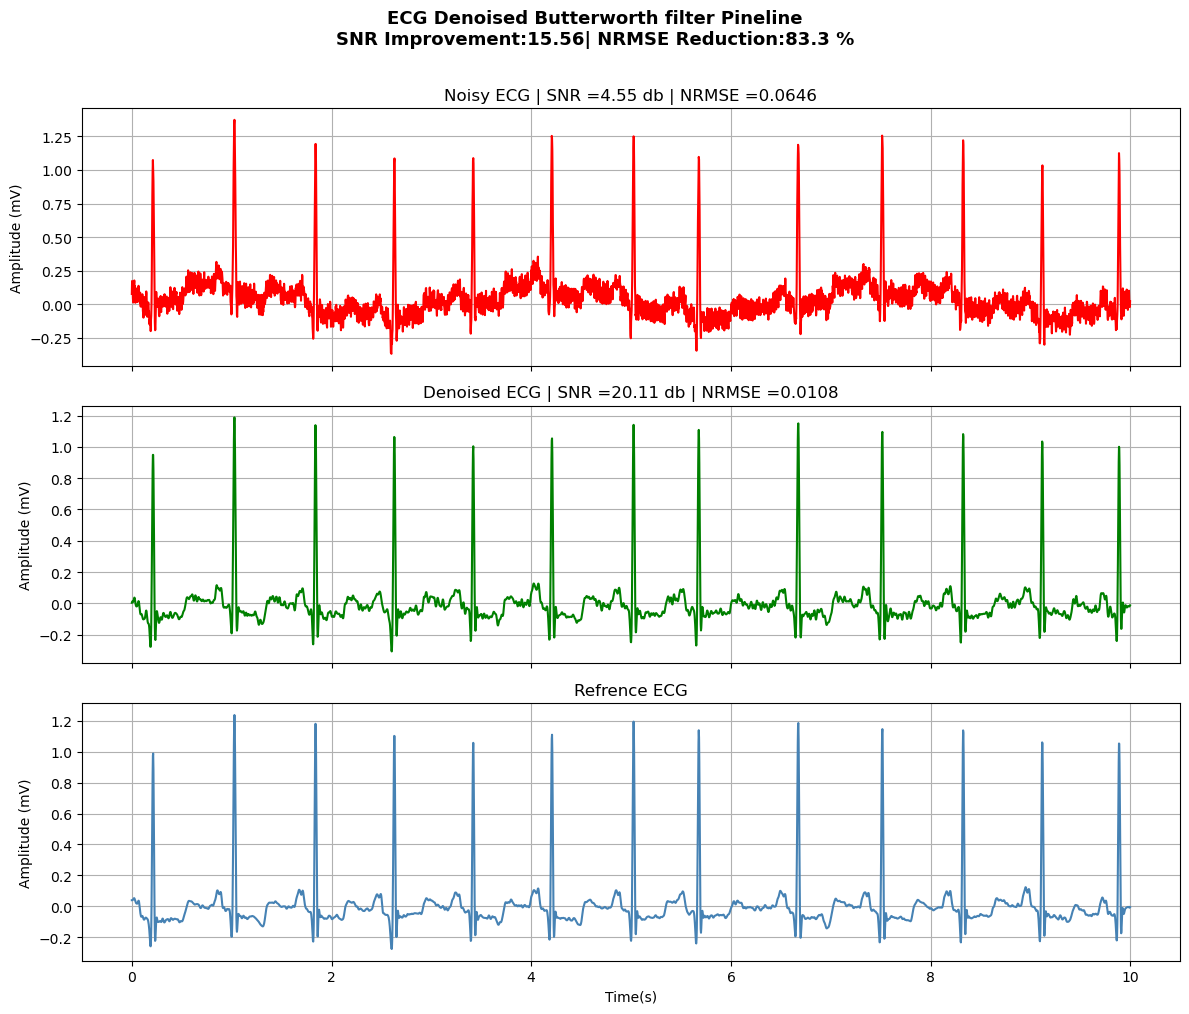

In [75]:
fig ,axes= plt.subplots(3,1,figsize=(12,10),sharex=True)

axes[0].plot(t,ecg_noisy,color='red')
axes[0].set_ylabel("Amplitude (mV)")
axes[0].set_title(f"Noisy ECG | SNR ={snr_before:0.2f} db | NRMSE ={nrmse_before :0.4f}")
axes[0].grid(True)

axes[1].plot(t,ecg_denoised,color='green')
axes[1].set_ylabel("Amplitude (mV)")
axes[1].set_title(f"Denoised ECG | SNR ={snr_after:0.2f} db | NRMSE ={nrmse_after :0.4f}")
axes[1].grid(True)

axes[2].plot(t,ecg_clean,color='steelblue')
axes[2].set_ylabel("Amplitude (mV)")
axes[2].set_title(f"Refrence ECG")
axes[2].set_xlabel("Time(s)")
axes[2].grid(True)

plt.suptitle(f"ECG Denoised Butterworth filter Pineline\nSNR Improvement:{snr_improvement:.2f}| NRMSE Reduction:{nrmse_reduction:0.1f} %",weight='bold',fontsize=13,y=1.01)
plt.tight_layout()
plt.savefig('output images/ecg_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
